### HIV VIRAL LOAD CASCADE ANALYSIS FOR THE REGION OF ANTHILL

#### BY DR OKEBUGWU ANDREW NWACHIMERE-EZE

### Background:
HIV has rapidly evolved into a manageable chronic disease due to improvement in scientific advancements over time. The usual "bag of bones" picture has drastically reduced, so is the transferability to sexual and biological contacts once the viral load is not detectable. This is refered to as U= U; undectable = untransmitable. Beyond the patient level and at the program level, the viral load cascade is calculated to show the performance across different age bands, subnationation units and at national level. This is the critial part of the 3rd 95 which means that 95% of persons on HIV drugs should have their viral load suppressed.

### Objectives
Are:

- To analyse a synthetic data to generate the viral load cascade for the geographic location.

- Disaggregate the viral load cascade according to health facilities

- Disaggrgate the viral load cascade according to different age bands

- Disaggregate the viral load cascade among the implementing partners programing in the region of Anthill. This will enable decision makers to take data driven decisions that will benefit the clients.

### Importing libraries

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

### Bringing in the synthetic dataset for the analysis.
The csv document named 'Data' is imported to a DataFrame is named "patient"

In [61]:
patient = pd.read_csv('Data.csv')

In [62]:
#Assessing the first 5 records in the data
patient.head()

,Partner,District,Hospital,Patient_Number,Weight,Last_Visit_Date,Sex,Birthdate,Age_at_ART_Initiation,Current_Age,Years_on_ART,ART_start_date,Last_drug_refill_date,last_drug_regimen,No_of_drugs,Viral_load,Date_of_Viral_Load,CurrentStatus_28
0,Kind_hearts,Agile,Coral Clinic,HR-VARRAV-VAR3VAR6,52.0,14-Dec-20,M,21/07/1974,37,51,14,26-Sept-11,NaN,NaN,NaN,NaN,NaN,Inactive
1,Kind_hearts,Agile,Coral Clinic,HRp-VAR9-VARVARAEV,38.0,03-Jun-25,M,06/05/1976,47,49,2,03-May-24,03-May-24,TDF-3TC-DTG,90.0,29.0,03-May-24,Inactive
2,Kind_hearts,Agile,Coral Clinic,HR-A9-VARBA36,65.0,24-Apr-25,F,01/01/1963,58,62,4,25-Feb-21,30-Aug-23,TDF-3TC-DTG,90.0,19.0,11-Jul-23,Inactive
3,Kind_hearts,Agile,Eastwest Clinic,EV6VAR,16.0,26-Jun-17,M,15/05/2002,17,23,6,22-Jan-20,08-Feb-23,TDF-3TC-DTG,180.0,19.0,02-Mar-22,Inactive
4,Kind_hearts,Agile,Coral Clinic,ANHBA,62.0,02-Jun-22,F,04/01/1963,51,62,11,25-Feb-14,09-Sept-25,TDF-3TC-DTG,90.0,20.0,29-Apr-25,Active


In [63]:
# To calculate number of rows and number of columns in the dataframe
#Data contains 293849 records and 18 fields
patient.shape

(293849, 18)

In [111]:
 # To Detect missing data (Non-Null Count)

# Verify data types before analysis

# Check dataset size and structure: Dates appear as object here and this will be corrected before analysis

patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293849 entries, 0 to 293848
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Partner                293849 non-null  object        
 1   District               293849 non-null  object        
 2   Hospital               293849 non-null  object        
 3   Patient_Number         293849 non-null  object        
 4   Weight                 276557 non-null  float64       
 5   Last_Visit_Date        280205 non-null  datetime64[ns]
 6   Sex                    293849 non-null  object        
 7   Birthdate              293849 non-null  object        
 8   Age_at_ART_Initiation  293849 non-null  int64         
 9   Current_Age            293849 non-null  int64         
 10  Years_on_ART           293849 non-null  int64         
 11  ART_start_date         293849 non-null  datetime64[ns]
 12  Last_drug_refill_date  283999 non-null  date

In [65]:
# Checking all the columns
patient.columns

Index(['Partner', 'District', 'Hospital', 'Patient_Number', 'Weight',
       'Last_Visit_Date', 'Sex', 'Birthdate', 'Age_at_ART_Initiation',
       'Current_Age', 'Years_on_ART', 'ART_start_date',
       'Last_drug_refill_date', 'last_drug_regimen', 'No_of_drugs',
       'Viral_load', 'Date_of_Viral_Load', 'CurrentStatus_28'],
      dtype='object')

### Data Cleaning
To evaluate for duplicates, missing values, inconsistencies in data


In [66]:
#To check for missing data
patient.isna().any(axis=1)

0          True
1         False
2         False
3         False
4         False
          ...  
293844     True
293845     True
293846     True
293847     True
293848     True
Length: 293849, dtype: bool

In [67]:
#To show cummulative missing values per column
patient.isna().sum()
#These columns will not affect the analysis hence, the null values were left untouched.


Partner                      0
District                     0
Hospital                     0
Patient_Number               0
Weight                   17292
Last_Visit_Date          13637
Sex                          0
Birthdate                    0
Age_at_ART_Initiation        0
Current_Age                  0
Years_on_ART                 0
ART_start_date               0
Last_drug_refill_date     9850
last_drug_regimen        17407
No_of_drugs               9850
Viral_load               61516
Date_of_Viral_Load       61516
CurrentStatus_28             0
dtype: int64

In [69]:
#To show cummulative missing values per column
patient.isna().sum().sum()
#The total number of missing values was 191068. As stated these columns are not important to our analysis and will be dropped subsequently


191068

In [70]:
#checking for duplicates
patient.duplicated().sum() #There are no duplicates

0

In [71]:
#To count ever enrolled patients disaggregated according to hospitals in  a descending order
patient["Hospital"].value_counts()

Hospital
Brookstone Hospital          46996
Liberty clinic               24545
Coral Clinic                 19803
Seecliff Hospital            19568
Yellow valley Clinic         18775
Newfield Hospital            18276
Gardenview Hospital          18200
Emerald clinic               17607
Autumn Clinic                15236
Meadow clinic                14909
Bluecliff Hospital           14700
Eastwest Clinic              11778
Horizon Hospital             11238
Orchard Hospital              8208
North Clinic                  7524
OakPeace Hospital             5453
Crystal clinic                4391
Lakeside clinic               3959
Beacon Hospital               3549
Liberty Hospital              2372
Clearwater Medical Centre     2341
Sunrise Hospital              2274
Serenity Hospital             2147
Name: count, dtype: int64

### Viral load analysis
Defining a function for VL analysis

""" This involves the following

(a) converting data types eg, the date columns appearing as object to date

(b) Defining the following:

(i) Delineate active patients also known as TX_CURR which are those currently on treatment 

(ii)Eligible for viral load: 6 months after commencement of Antiretroviral therapy 

(iii) Valid results: Viral load results that are less than 1 year from the period of review

(iv) Suppressed results: Viral load results that are below 1000 copies per ml"""



In [72]:
# Conversion of dates to datetime
date_cols = ["Last_Visit_Date", "ART_start_date", "Last_drug_refill_date", "Date_of_Viral_Load"]
for col in date_cols:
    patient[col] = pd.to_datetime(patient[col], errors="coerce")


In [73]:
 #Creating Age Group Variable


def assign_age_group(age):
    if pd.isna(age):
        return "Unknown"
    age = int(age)
    if age < 15:
        return "Child"
    elif 15 <= age <= 19:
        return "Adolescent"
    else:
        return "Adult"

patient["Age_Group"] = patient["Current_Age"].apply(assign_age_group)


In [78]:
 #Filtering the viral load variables

# a) Filter patients who are still active on HIV drugs
tx_curr = patient[patient["CurrentStatus_28"].str.lower() == "active"]

 # Establish Cutoff dates for eligibility. This is usually those who have been on drugs for at least six months before the analysis day.
# Here the 4th of December 2025 was used as analysis date hence 6 months before was 3rd of June 2025.

analysis_date = pd.Timestamp.today()
cutoff_eligibility = pd.to_datetime("2025-06-03")
one_year_back = analysis_date - pd.DateOffset(years=1)

#Establish cutoff date for validity of results. This is usually results of samples collected one year before the analysis date
cutoff_valid = pd.Timestamp.today() - pd.DateOffset(years=1)
valid_result = eligible[
    eligible["Date_of_Viral_Load"].between(cutoff_valid, pd.Timestamp.today())
]

  # Eligible (≥ 6 months on ART)
#eligible = tx_curr[
       # tx_curr["ART_start_date"] < cutoff_eligibility
   # ]

    # Valid VL results (within 1 year to today)
#valid_result = eligible[
        #eligible["Date_of_Viral_Load"].between(
           # one_year_back,
           # analysis_date,
          #  inclusive="both"
      #  )
#]
# Delineating suppressed viral load for those with valid results with viral load values of 
suppressed = valid_result[valid_result["Viral_load"] < 1000]


### Definition of function to create summary table for the analysis

In [79]:


def create_summary(df_tx, df_eligible, df_valid, df_suppressed, group_col=None):
    if group_col:
        summary = pd.DataFrame({
            "TX_CURR": df_tx.groupby(group_col).size(),
            "Eligible": df_eligible.groupby(group_col).size(),
            "Valid VL Results": df_valid.groupby(group_col).size(),
            "Suppressed": df_suppressed.groupby(group_col).size()
        }).fillna(0).astype(int)
        summary["VL Coverage (%)"] = round(summary["Valid VL Results"] / summary["Eligible"] * 100, 2)
        summary["VL Suppression (%)"] = round(summary["Suppressed"] / summary["Valid VL Results"] * 100, 2)
        summary = summary.reset_index()
        
        # To add total row as a summation to all the columns
        total_row = pd.DataFrame({
            group_col: ["TOTAL"],
            "TX_CURR": [summary["TX_CURR"].sum()],
            "Eligible": [summary["Eligible"].sum()],
            "Valid VL Results": [summary["Valid VL Results"].sum()],
            "Suppressed": [summary["Suppressed"].sum()],
            "VL Coverage (%)": [round(summary["Valid VL Results"].sum() / summary["Eligible"].sum() * 100, 2)],
            "VL Suppression (%)": [round(summary["Suppressed"].sum() / summary["Valid VL Results"].sum() * 100, 2)]
        })
        summary = pd.concat([summary, total_row], ignore_index=True)
        return summary
    else:
        # General summary
        summary_data = {
            "Indicator": [
                "TX_CURR",
                "Eligible",
                "Valid VL Results",
                "Suppressed",
                "VL Coverage (%)",
                "VL Suppression (%)"
            ],
            "Value": [
                len(df_tx),
                len(df_eligible),
                len(df_valid),
                len(df_suppressed),
                round(len(df_valid) / len(df_eligible) * 100, 2) if len(df_eligible) > 0 else 0,
                round(len(df_suppressed) / len(df_valid) * 100, 2) if len(df_valid) > 0 else 0
            ]
        }
        #storing the above as a variable "summary"
        summary = pd.DataFrame(summary_data)
        # Convert counts to int
        summary.loc[0:3, "Value"] = summary.loc[0:3, "Value"].astype(int)
        return summary

In [80]:
#Creating summary tables for all the tables
general_summary = create_summary(tx_curr, eligible, valid_result, suppressed)
age_summary = create_summary(tx_curr, eligible, valid_result, suppressed, "Age_Group")
hospital_summary = create_summary(tx_curr, eligible, valid_result, suppressed, "Hospital")
partner_summary = create_summary(tx_curr, eligible, valid_result, suppressed, "Partner")
district_summary = create_summary(tx_curr, eligible, valid_result, suppressed, "District")


In [81]:
#printing the general cascade table
print("\n===== GENERAL VL CASCADE =====")
display(general_summary)


===== GENERAL VL CASCADE =====


,Indicator,Value
0,TX_CURR,149432.00
1,Eligible,147514.00
2,Valid VL Results,106639.00
3,Suppressed,103617.00
4,VL Coverage (%),72.29
5,VL Suppression (%),97.17


#### Plotting the general VL cascade

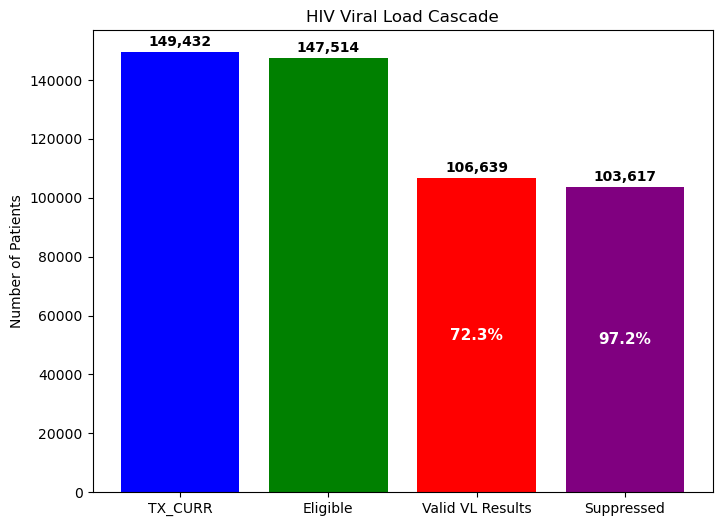

In [99]:
#Delineating the indicators and values from the last analysis
data = {
    "indicators": ["TX_CURR", "Eligible", "Valid VL Results", "Suppressed"],
    "Value": [int(149432.00), int(147514.00), int(106639.00), int(103617.00)]
}

# Extracting the lists
indicators = data["indicators"]
values = data["Value"]

#Calculating Percentages for Viral load coverage and viral load suppression
coverage_pct = (106639 / 147514) * 100
suppression_pct = (103617 / 106639) * 100
percentages = ["", "", f"{coverage_pct:.1f}%", f"{suppression_pct:.1f}%"]

# Plotting the data on a bar chart and selecting bar colors and figure size
fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(indicators, values, color=["blue", "green", "red", "purple"])

# Add values and percentages as labels
for bar, value, pct in zip(bars, values, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1000, f"{value:,}", 
            ha='center', va='bottom', fontsize=10, weight="bold")
    if pct:
        ax.text(bar.get_x() + bar.get_width()/2, height/2, pct, 
                ha='center', va='center', fontsize=11, color="white", weight="bold")

# Formatting the chart, adding labels and title 
ax.set_ylabel("Number of Patients")
ax.set_title("HIV Viral Load Cascade")
plt.savefig("general.png")
plt.show()

### Deeper dive analysis and visualization of the viral load cascde disaggregated by hospitals, age-band, district and partner

In [104]:
"""
    Plotting a multi-bar combo chart with TX_CURR, Eligible, Valid VL Results, Suppressed as bars
    and VL Coverage (%) and VL Suppression (%) as line graphs, including data labels.
    
    summary_df: Summary DataFrame with totals included
    group_col: Column for x-axis (e.g., Age_Group, Partner, District)
    """

def plot_multi_bar_combo_with_labels(summary_df, group_col, title="VL Cascade"):
   
    
    # Excluding total row
    plot_df = summary_df[summary_df[group_col] !="TOTAL"].copy()
    
    # x-axis
    x = np.arange(len(plot_df))
    width = 0.2  # Width of each bar
    
    fig, ax1 = plt.subplots(figsize=(14,6))
    
    # Plot bars
    bars1 = ax1.bar(x - 1.5*width, plot_df["TX_CURR"], width, label="TX_CURR", color="skyblue")
    bars2 = ax1.bar(x - 0.5*width, plot_df["Eligible"], width, label="Eligible", color="green")
    bars3 = ax1.bar(x + 0.5*width, plot_df["Valid VL Results"], width, label="Valid VL Results", color="orange")
    bars4 = ax1.bar(x + 1.5*width, plot_df["Suppressed"], width, label="Suppressed", color="purple")
    
    # Add data labels on bars
    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2, height + 500, f"{int(height):,}",
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax1.set_ylabel("Number of Patients")
    ax1.set_xticks(x)
    ax1.set_xticklabels(plot_df[group_col], rotation=45, ha="right")
    
    # Twin axis for percentages
    ax2 = ax1.twinx()
    line1, = ax2.plot(x, plot_df["VL Coverage (%)"], color="red", marker="o", label="VL Coverage (%)", linewidth=2)
    line2, = ax2.plot(x, plot_df["VL Suppression (%)"], color="black", marker="o", label="VL Suppression (%)", linewidth=2)
    ax2.set_ylabel("Percentage (%)")
    ax2.set_ylim(0, 110)
    
    # Add data labels on lines
    for i, (vlc, vls) in enumerate(zip(plot_df["VL Coverage (%)"], plot_df["VL Suppression (%)"])):
        ax2.text(x[i], vlc + 1, f"{vlc:.2f}%", ha='center', va='bottom', color="red", fontsize=9, fontweight='bold')
        ax2.text(x[i], vls + 1, f"{vls:.2f}%", ha='center', va='bottom', color="black", fontsize=9, fontweight='bold')
    
    # Combine legends
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")
    
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [84]:
# Displaying the age band cascade of the analysis
print("\n===== AGE GROUP SUMMARY =====")
display(age_summary)


===== AGE GROUP SUMMARY =====


,Age_Group,TX_CURR,Eligible,Valid VL Results,Suppressed,VL Coverage (%),VL Suppression (%)
0,Adolescent,2186,2098,1890,1732,90.09,91.64
1,Adult,144508,142758,102372,99710,71.71,97.40
2,Child,2738,2658,2377,2175,89.43,91.50
3,TOTAL,149432,147514,106639,103617,72.29,97.17


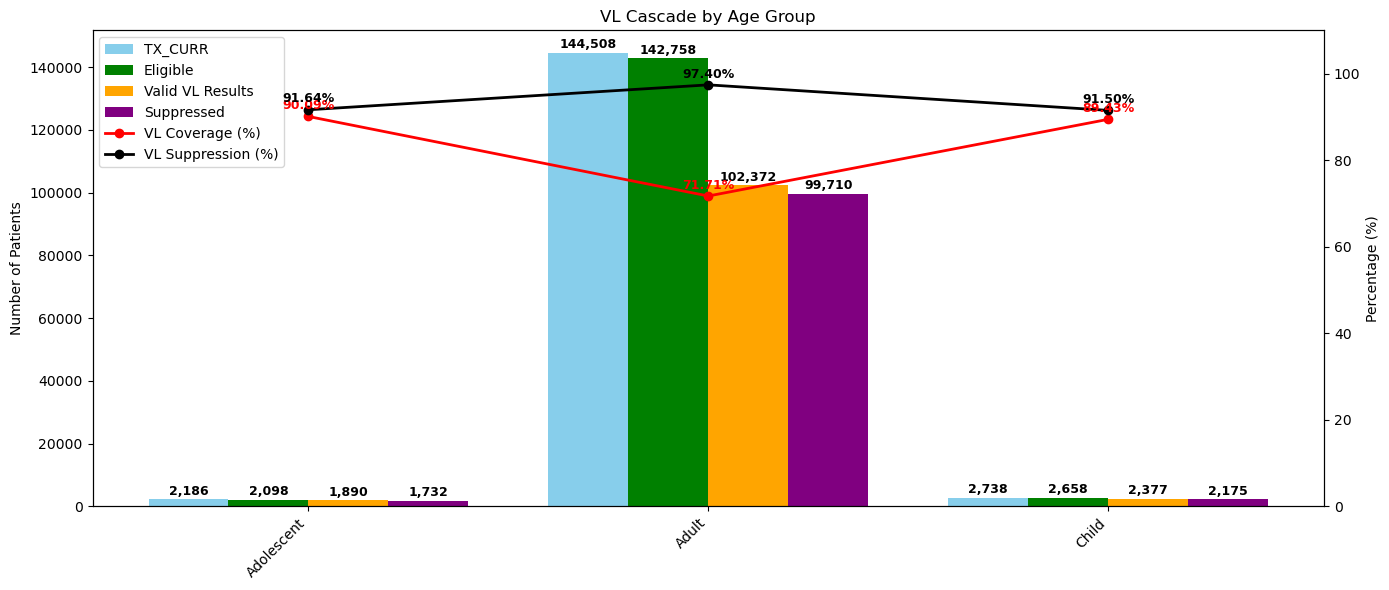

In [105]:
# Age Group
plot_multi_bar_combo_with_labels(age_summary, "Age_Group", title="VL Cascade by Age Group")


In [85]:
# Displaying the cascade by hospitals of the analysis
print("\n===== HOSPITAL SUMMARY =====")
display(hospital_summary)


===== HOSPITAL SUMMARY =====


,Hospital,TX_CURR,Eligible,Valid VL Results,Suppressed,VL Coverage (%),VL Suppression (%)
0,Autumn Clinic,7281,7200,5205,5076,72.29,97.52
1,Beacon Hospital,1970,1929,1422,1382,73.72,97.19
2,Bluecliff Hospital,8093,7955,5487,5379,68.98,98.03
3,Brookstone Hospital,23204,22970,16727,16236,72.82,97.06
4,Clearwater Medical Centre,1329,1315,975,950,74.14,97.44
5,Coral Clinic,9664,9564,7006,6798,73.25,97.03
6,Crystal clinic,2414,2380,1733,1685,72.82,97.23
7,Eastwest Clinic,5549,5480,3969,3845,72.43,96.88
8,Emerald clinic,9754,9597,7004,6815,72.98,97.30
9,Gardenview Hospital,9433,9290,6757,6552,72.73,96.97


In [86]:
# Showing the cascade based on the partners implementing in the region
print("\n===== PARTNER SUMMARY =====")
display(partner_summary)



===== PARTNER SUMMARY =====


,Partner,TX_CURR,Eligible,Valid VL Results,Suppressed,VL Coverage (%),VL Suppression (%)
0,Kind_hearts,112452,111220,80090,77770,72.01,97.10
1,Mean,36980,36294,26549,25847,73.15,97.36
2,TOTAL,149432,147514,106639,103617,72.29,97.17


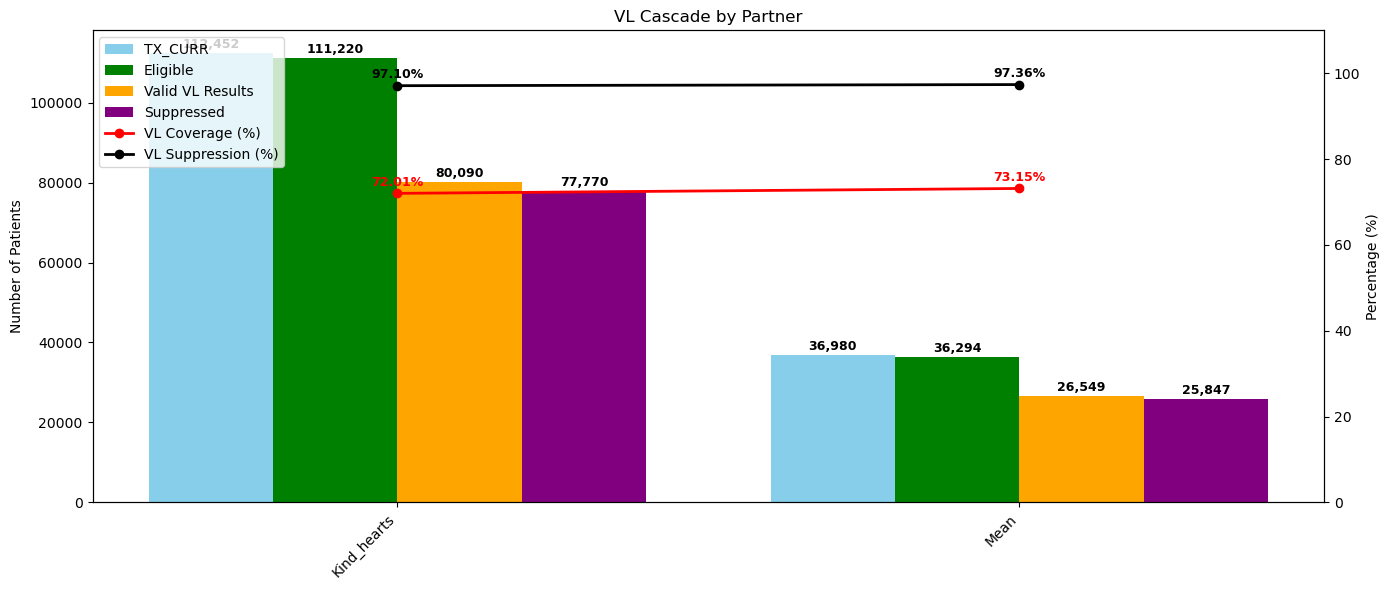

In [109]:
# Partner plot
plot_multi_bar_combo_with_labels(partner_summary, "Partner", title="VL Cascade by Partner")

In [87]:
# Viral Load cascade by district
print("\n===== DISTRICT SUMMARY =====")
display(district_summary)



===== DISTRICT SUMMARY =====


,District,TX_CURR,Eligible,Valid VL Results,Suppressed,VL Coverage (%),VL Suppression (%)
0,Agile,29737,29362,21140,20516,72.00,97.05
1,Benefit,1640,1622,1183,1152,72.93,97.38
2,Capable,18213,18043,13054,12662,72.35,97.00
3,Cargo,27609,27288,19901,19328,72.93,97.12
4,Excellent,17747,17448,12375,12058,70.93,97.44
5,Haven,3407,3349,2452,2393,73.22,97.59
6,Light,16011,15798,11501,11193,72.80,97.32
7,Marble,3494,3470,2521,2461,72.65,97.62
8,Quest,12394,12219,8759,8503,71.68,97.08
9,Seaside,9390,9282,6721,6509,72.41,96.85


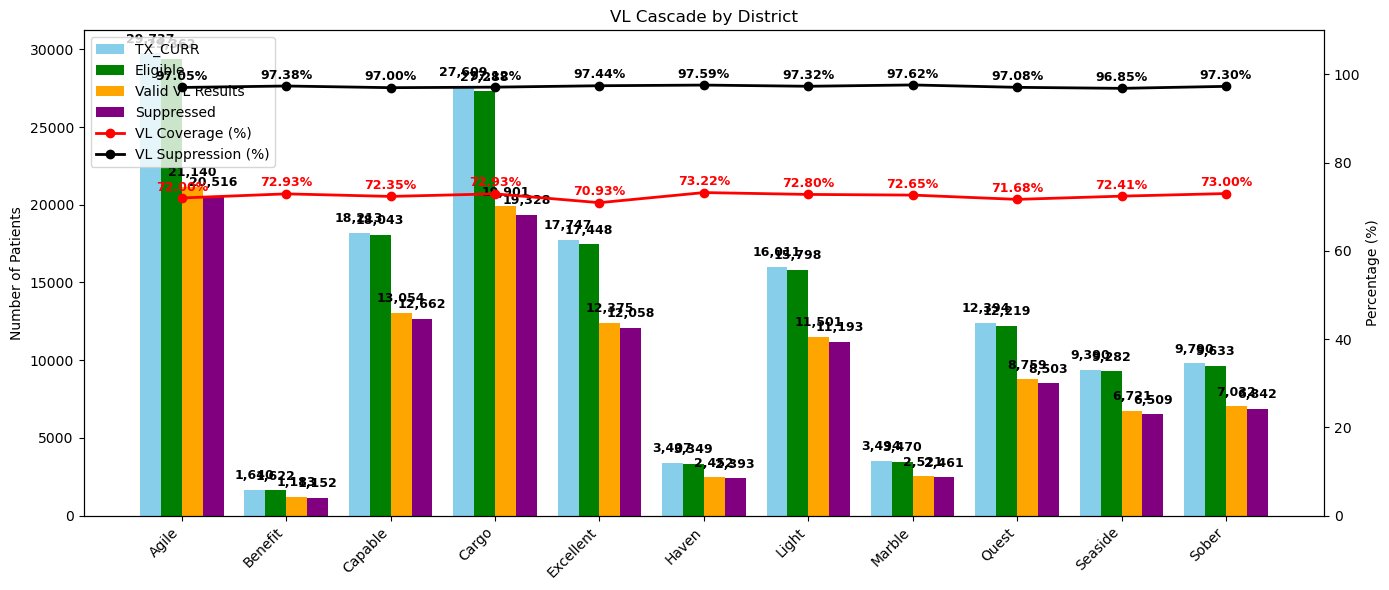

In [110]:
# Plotting the district summary
plot_multi_bar_combo_with_labels(district_summary, "District", title="VL Cascade by District")

### Key findings

1. The viral load coverage (VLC) is at 72.3% a far cry from the expected 95%
2. The viral load suppression (VLS) was 97% which means this is higher than the 95% goal for viral suppression
3. Age group analysis shows that the adolescent age band had the best VLC while the adult had the least while the suppression showed that Adult cohort had the highest with the child category having the least VLS. However, only the adult cohort achieved optimal vLS.
4. In terms of hospitals, the highest and least VLC were from Clearwater Medical Centre and Bluecliff Hospital respectively while the highest and least VLS were for Bluecliff and Horizon Hospitals respectively. However, it is important to note that all the hospitals achieved optimal VLS
5. Mean implementing partner had the best VLC and VLS though the VLC was still suboptimal.
6. For district analysis, Haven and Agile district had the highest and lowest VLC  while Marble and Seaside districts achieved the highest and lowest VLS respectively. All districts however achieved Viral 


### Points to note
1. Only results were analysed, so samples at the PCR lab were not taken into consideration. This may affect the VLC.